In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())

Train shape: (1460, 81)
Test shape: (1459, 80)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  S

In [2]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
for col in none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

num_cols = train.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

for col in train.select_dtypes(include=['object']).columns:
    if train[col].nunique() < 10:
        train[col] = train[col].astype('category')
        test[col] = test[col].astype('category')

float_cols = train.select_dtypes(include=['float64']).columns
train[float_cols] = train[float_cols].astype('float32')
test[float_cols] = test[float_cols].astype('float32')

# Outliers
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)

if train['SalePrice'].max() > 100:
    train['SalePrice'] = np.log1p(train['SalePrice'])

print("Data cleaning and memory optimization completed successfully!")

Data cleaning and memory optimization completed successfully!


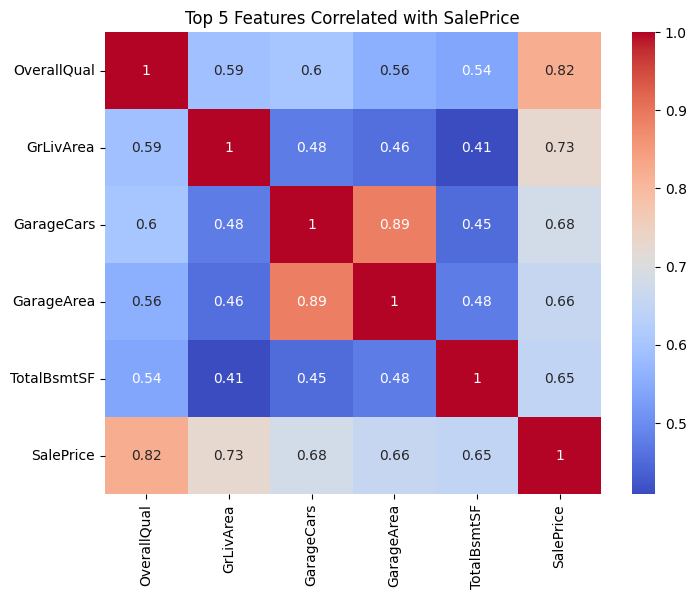

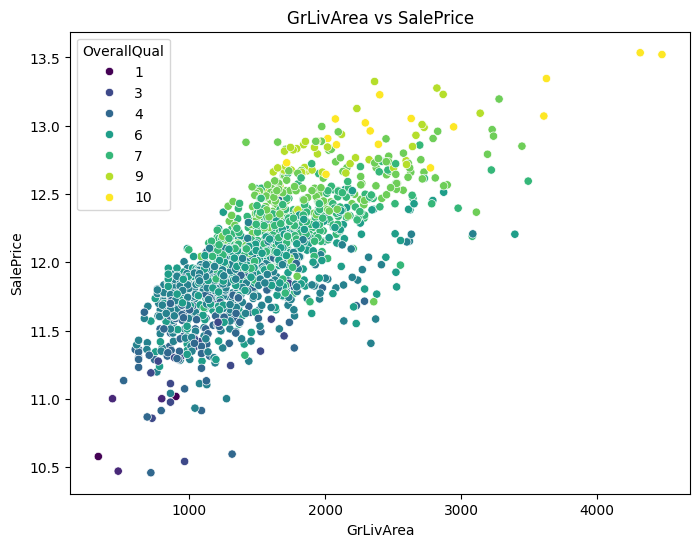

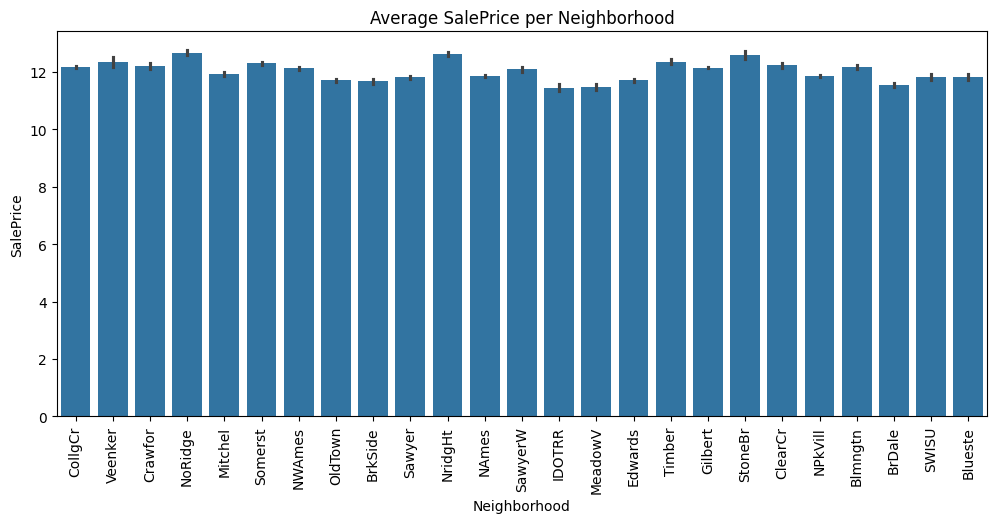

In [3]:
corr_matrix = train.select_dtypes(include=[np.number]).corr()
top_5_features = corr_matrix['SalePrice'].sort_values(ascending=False).index[1:6]

plt.figure(figsize=(8, 6))
sns.heatmap(train[list(top_5_features) + ['SalePrice']].corr(), annot=True, cmap='coolwarm')
plt.title('Top 5 Features Correlated with SalePrice')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis')
plt.title('GrLivArea vs SalePrice')
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=train, x='Neighborhood', y='SalePrice', estimator=np.mean)
plt.xticks(rotation=90)
plt.title('Average SalePrice per Neighborhood')
plt.show()

In [4]:
def run_feature_engineering(df_data, is_train=True):
    df_out = df_data.copy()

    df_out['TotalSF'] = df_out['TotalBsmtSF'] + df_out['1stFlrSF'] + df_out['2ndFlrSF']

    qual_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0, 'None': 0}
    for col in ['ExterQual', 'KitchenQual']:
        if col in df_out.columns:
            df_out[col] = df_out[col].map(qual_map).fillna(2)

    return df_out

# تطبيق الدالة على المجموعتين لمنع حدوث Data Leakage
train_proc = run_feature_engineering(train, is_train=True)
test_proc = run_feature_engineering(test, is_train=False)

# ترميز فئات للميزات الاسمية (One-Hot Encoding) باستخدام get_dummies بشكل موحد
combined = pd.concat([train_proc.drop(columns=['SalePrice'], errors='ignore'), test_proc], axis=0)
combined = pd.get_dummies(combined, columns=['Neighborhood', 'BldgType'], drop_first=True)

# إعادة فصل البيانات بعد الـ One-Hot Encoding
X_train_final = combined.iloc[:len(train_proc)].copy()
X_test_final = combined.iloc[len(train_proc):].copy()
y_train_final = train_proc['SalePrice']

print("Final Processed Train Features Shape:", X_train_final.shape)

Final Processed Train Features Shape: (1458, 107)
